# Example calculation 

In this example we showcase the basic functionality of the cable thermal model project.

## Required input

To run a thermal calculation we need two things.

1. A *static environment*, specifying the cable types and the geometry of the cable circuits.
The static environment contains information that does not change over time such as
    - Cable constructional information.
    - Optionally, constructional information of pipes that contain a circuit.
    - The position of the circuits with respect to each other (for circuits in soil).
    - The circuit type, e.g., trefoil.
    - The bonding type.

    We use the `StaticEnvSoil` and `StaticEnvAir` classes to model static environments for cables in soil and air respectively.

2. A *scenario*. This is a pandera dataframe specifying time dependent parameters, such as
    - The ambient temperature.
    - The load (in Ampère) for each circuit.
    - Thermal properties of the soil (for circuits in soil).
    
    We use the `ScenarioSchemaSoil` and `ScenarioSchemaAir` respectively to model the scenario for cables in soil and air respectively.

## Cables in soil

We first consider an example for cables in soil. In this example we use example cables from the `data/example_cable.csv` file.
See *build cable example* for an example of how to use other cable types.

### Static Environment

We start by constructing the static environment.

In [ ]:
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cable_thermal_model import (
    BondingType,
    CableLayer,
    CablePosition,
    CircuitType,
    ModelFactory,
    PipeFillType,
    PipeInputSchema,
    StaticEnvSoil,
)
from cable_thermal_model.cable.schemas.circuit_schemas import (
    CircuitInAirFromCableIdInputSchema,
    CircuitInSoilFromCableIdInputSchema,
)
from cable_thermal_model.model.schemas import ScenarioSchemaSoil

static_env = StaticEnvSoil()

# We add two cables to the environment at the same depth of 1 m, and 0.2 m apart from each other.
# The first circuit is a single circuit inside a pipe, while the second circuit is a linear circuit without a pipe.
# For the first circuit we do not specify the circuit type and bonding type,
# so they default to 'CircuitType.Single' and 'BondingType.NoBonding'.
circuit_input_1 = CircuitInSoilFromCableIdInputSchema(
    x=0.2,  # The second circuit lies 20 cm away from the first circuit
    y=-1,
    circuit_name="circuit_1",
    cable_id="GPLK 10/10 kV 3x185 Al",
    cable_source_file_path="../../data/example_cables.csv",
    pipe=PipeInputSchema(
        fill_type=PipeFillType.Water,
        outer_radius=0.08,  # 160 mm outer diameter
        sdr=11,
    ),
)
circuit_input_2 = CircuitInSoilFromCableIdInputSchema(
    x=0,
    y=-1,
    circuit_name="circuit_2",
    cable_id="YMeKrvaslqwd 12/20kV 1x630 Alrm + as50",
    cable_source_file_path="../../data/example_cables.csv",
    circuit_type=CircuitType.Linear,
    bonding_type=BondingType.TwoSided,
)

# Add the circuits to the environment.
static_env.add_circuit_from_cable_id(circuit_input_1)
static_env.add_circuit_from_cable_id(circuit_input_2)

StaticEnvSoil
	Circuit circuit_1
		Type: SingleCable
		BondingType: no_bonding
		x: 0.2
		y: -1.0
	Circuit circuit_2
		Type: LinearCircuit
		BondingType: two_sided
		x: 0.0
		y: -1.0

### Scenario

Next, we create a scenario containing the time dependent variables.
For cables in soil, the following columns need to be present in the scenario dataframe:
- `load_{circuit_name}`: load for every circuit added to the environment.
- `ambient_temperature`: temperature of the soil surrounding the cables.
- `soil_thermal_resistivity`: thermal resistivity of the soil surrounding the cables.
- `soil_thermal_capacity`: thermal capacity of the soil surrounding the cables.

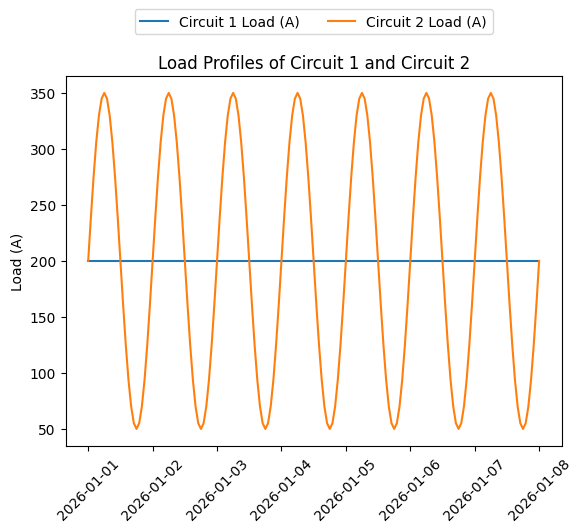

In [ ]:
# In this case we use a scenario that lasts for a week with a step size of 1 hour.
START_DATE = datetime(2026, 1, 1)
DAYS_TO_SIMULATE = 7

scenario = pd.DataFrame(
    index=pd.date_range(start=START_DATE, end=START_DATE + pd.Timedelta(days=DAYS_TO_SIMULATE), freq="1h")
)

# We set the load of the first circuit to 200A for the entire week, while we model the load of the second circuit
# as a sinusoidal function that oscillates between 50 and 350A with a period of 24 hours.
scenario["load_circuit_1"] = 200
scenario["load_circuit_2"] = 200 + 150 * np.sin(2 * np.pi * scenario.index.hour / 24)
scenario["ambient_temperature"] = 15  # Ambient temperature is assumed to be constant at 15 degrees Celsius.
scenario["soil_thermal_resistivity"] = 0.75  # Soil thermal resistivity is assumed to be constant at 0.75 mK/W.
scenario["soil_thermal_capacity"] = 2e6  # Soil thermal capacity is assumed to be constant at 2e6 J/(m³K).

# Cast and validate the scenario using the ScenarioSchemaSoil. The scenario will also be validated when
# passed to the model, so this is mainly useful to catch errors early on.
validated_scenario = ScenarioSchemaSoil.validate(scenario)

# Plot the load profiles of the two circuits.
plt.plot(validated_scenario.index, validated_scenario["load_circuit_1"], label="Circuit 1 Load (A)")
plt.plot(validated_scenario.index, validated_scenario["load_circuit_2"], label="Circuit 2 Load (A)")
plt.ylabel("Load (A)")
plt.title("Load Profiles of Circuit 1 and Circuit 2")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)
plt.xticks(rotation=45)
plt.show()

### Model

After creating the static environment and the scenario, we can run the model. 

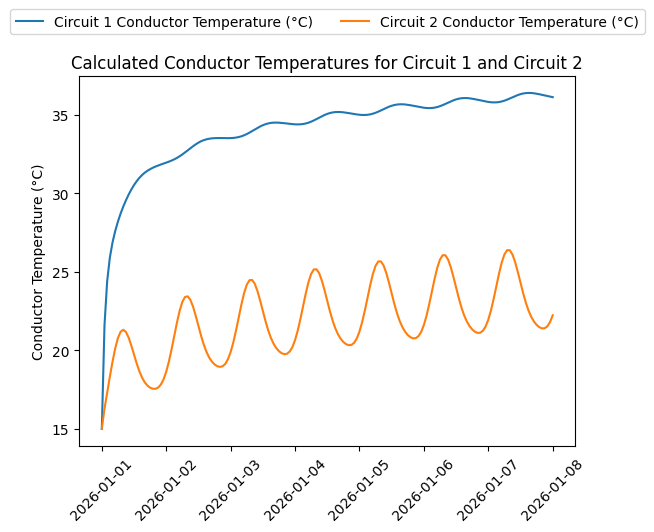

In [ ]:
model = ModelFactory.create_model(static_env=static_env, scenario=validated_scenario)
solution = model.run()
temperature_result = solution.result

# Plot the calculated conductor temperatures for both circuits.
# For the second circuit, we plot the temperature of the conductor in the linear center position.
plt.plot(
    temperature_result.index,
    temperature_result["circuit_1"][CablePosition.Single][CableLayer.Conductor],
    label="Circuit 1 Conductor Temperature (°C)",
)
plt.plot(
    temperature_result.index,
    temperature_result["circuit_2"][CablePosition.LinearCenter][CableLayer.Conductor],
    label="Circuit 2 Conductor Temperature (°C)",
)
plt.ylabel("Conductor Temperature (°C)")
plt.title("Calculated Conductor Temperatures for Circuit 1 and Circuit 2")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)
plt.xticks(rotation=45)
plt.show()

### Stateful computations

The solution object contains a state, which stores internal temperature information of the cables within the circuit at the end of the simulation. It can be used to continue a previous calculation, for example due to availability of new data. In the example below we run the model for another week, starting from the previous solution.

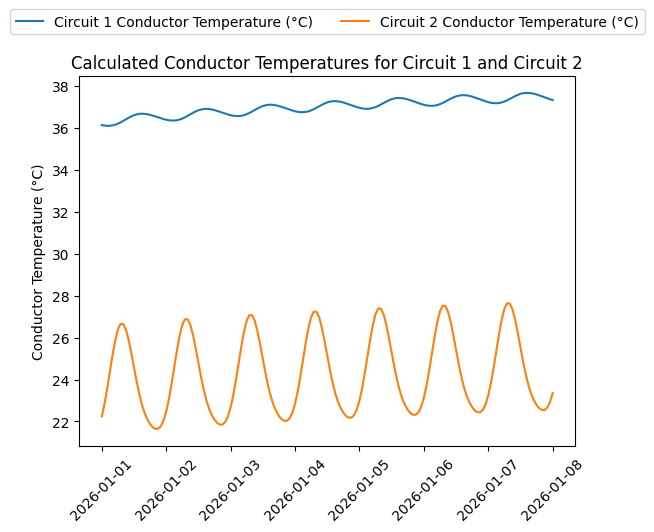

In [ ]:
final_state = solution.state
stateful_solution = model.run(initial_state=final_state)
stateful_temperature_result = stateful_solution.result

plt.plot(
    stateful_temperature_result.index,
    stateful_temperature_result["circuit_1"][CablePosition.Single][CableLayer.Conductor],
    label="Circuit 1 Conductor Temperature (°C)",
)
plt.plot(
    stateful_temperature_result.index,
    stateful_temperature_result["circuit_2"][CablePosition.LinearCenter][CableLayer.Conductor],
    label="Circuit 2 Conductor Temperature (°C)",
)
plt.ylabel("Conductor Temperature (°C)")
plt.title("Calculated Conductor Temperatures for Circuit 1 and Circuit 2")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)
plt.xticks(rotation=45)
plt.show()

## Cables in air

Running the model for cables in air is done similarly for cables in soil. In air, only one circuit can be added to the static environment.

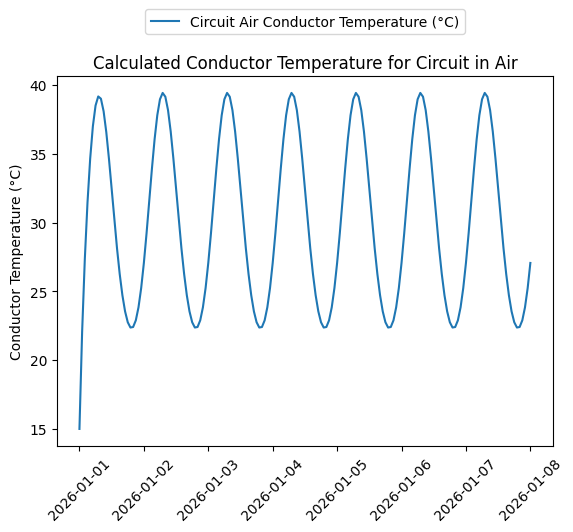

In [ ]:
from cable_thermal_model import StaticEnvAir

static_env_air = StaticEnvAir()

circuit_input_air = CircuitInAirFromCableIdInputSchema(
    circuit_name="circuit_air",
    cable_id="YMeKrvaslqwd 12/20kV 1x630 Alrm + as50",
    cable_source_file_path="../../data/example_cables.csv",
    circuit_type=CircuitType.LinearVertical,
    bonding_type=BondingType.TwoSided,
)

static_env_air.add_circuit_from_cable_id(circuit_input_air)

scenario_air = pd.DataFrame(
    index=pd.date_range(start=START_DATE, end=START_DATE + pd.Timedelta(days=DAYS_TO_SIMULATE), freq="1h")
)
# Only the load of the circuit and the ambient temperature are relevant for the air model.
scenario_air["load_circuit_air"] = 400 + 150 * np.sin(2 * np.pi * scenario_air.index.hour / 24)
scenario_air["ambient_temperature"] = 15  # 15 degrees Celsius

model_air = ModelFactory.create_model(static_env=static_env_air, scenario=scenario_air)
solution_air = model_air.run()
temperature_result_air = solution_air.result
plt.plot(
    temperature_result_air.index,
    temperature_result_air["circuit_air"][CablePosition.LinearTop][CableLayer.Conductor],
    label="Circuit Air Conductor Temperature (°C)",
)
plt.ylabel("Conductor Temperature (°C)")
plt.title("Calculated Conductor Temperature for Circuit in Air")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3)
plt.xticks(rotation=45)
plt.show()